In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# تحميل البيانات (تأكد من اسم الملف)
df = pd.read_csv('amazon.csv')

In [5]:
print(df.columns)

Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue'],
      dtype='object')


In [6]:
# 1. تنظيف الأسعار والخصومات (باستخدام الأسماء الصحيحة عندك)
# سنقوم بتحويلها لنصوص أولاً ثم تنظيفها كما فعلنا
cols_to_clean = ['price', 'discounted_price', 'total_revenue']

for col in cols_to_clean:
    if col in df.columns:
        # إزالة أي رموز عملات أو فواصل لو وجدت وتحويلها لـ float
        df[col] = df[col].astype(str).str.replace('₹', '').str.replace(',', '').str.replace('$', '').astype(float)

# 2. تنظيف نسبة الخصم (عندك اسمها discount_percent)
df['discount_percent'] = df['discount_percent'].astype(str).str.replace('%', '').astype(float)

# 3. معالجة القيم المفقودة
df.dropna(inplace=True)

# 4. إنشاء عمود الهدف (Performance) بناءً على Revenue (الإيرادات)
# سنقسم الإيرادات إلى 3 فئات
df['performance'] = pd.qcut(df['total_revenue'], q=3, labels=['Low', 'Medium', 'High'])

# 5. اختيار الميزات (Feature Selection) بناءً على أعمدتك
# سنستخدم السعر، نسبة الخصم، التقييم، والكمية المباعة
features = ['price', 'discount_percent', 'rating', 'quantity_sold']
X = df[features]
y = df['performance']

# 6. التشفير للفئات النصية لو أردت إدخال Category
le = LabelEncoder()
df['product_category_encoded'] = le.fit_transform(df['product_category'])
# إضافة الكاتيجوري للميزات
X = df[features + ['product_category_encoded']]

# 7. السكيلر والـ PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("تم تجهيز البيانات والـ PCA بنجاح!")

تم تجهيز البيانات والـ PCA بنجاح!


In [8]:
# تقسيم البيانات: 80% تدريب و 20% اختبار
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

print(f"حجم بيانات التدريب: {X_train.shape[0]}")
print(f"حجم بيانات الاختبار: {X_test.shape[0]}")

حجم بيانات التدريب: 40000
حجم بيانات الاختبار: 10000


In [9]:
# 1. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_acc = rf.score(X_test, y_test)

# 2. Support Vector Machine (SVM)
svm = SVC(kernel='rbf', C=1.0)
svm.fit(X_train, y_train)
svm_acc = svm.score(X_test, y_test)

print(f"دقة Random Forest: {rf_acc*100:.2f}%")
print(f"دقة SVM: {svm_acc*100:.2f}%")

دقة Random Forest: 70.18%
دقة SVM: 72.60%


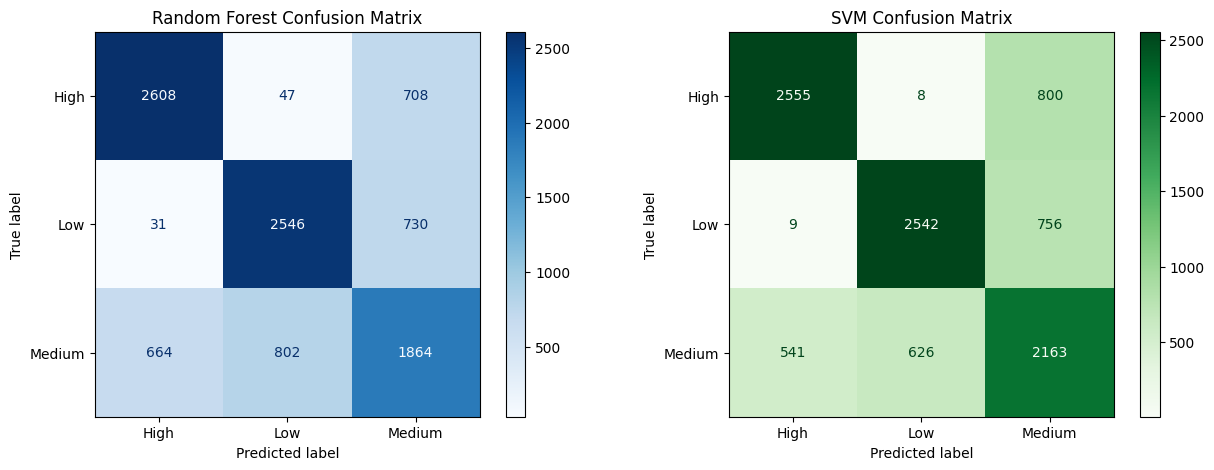

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

# رسم الـ Confusion Matrix لموديل Random Forest
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, ax=ax[0], cmap='Blues')
ax[0].set_title('Random Forest Confusion Matrix')

# رسم الـ Confusion Matrix لموديل SVM
ConfusionMatrixDisplay.from_estimator(svm, X_test, y_test, ax=ax[1], cmap='Greens')
ax[1].set_title('SVM Confusion Matrix')

plt.show()

In [11]:
from sklearn.metrics import classification_report

# توقع النتائج لبيانات الاختبار
rf_predictions = rf.predict(X_test)

print("--- تقرير أداء Random Forest ---")
print(classification_report(y_test, rf_predictions))

--- تقرير أداء Random Forest ---
              precision    recall  f1-score   support

        High       0.79      0.78      0.78      3363
         Low       0.75      0.77      0.76      3307
      Medium       0.56      0.56      0.56      3330

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



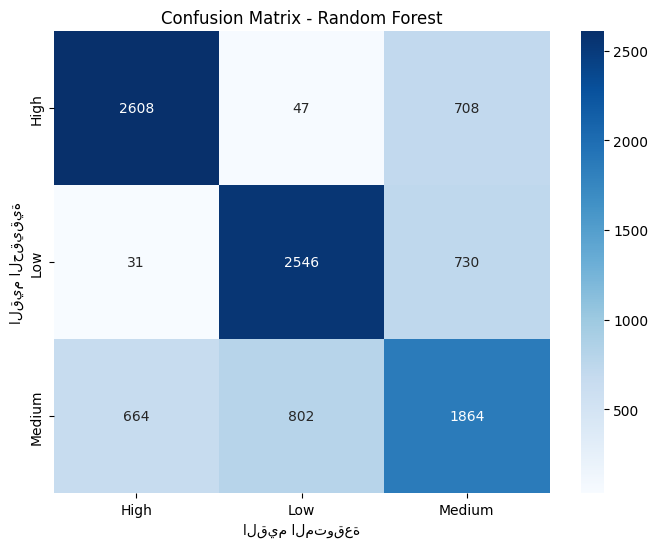

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, rf_predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['High', 'Low', 'Medium'],
            yticklabels=['High', 'Low', 'Medium'])
plt.ylabel('القيم الحقيقية')
plt.xlabel('القيم المتوقعة')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [13]:
# أدخل بيانات منتج جديد بنفس ترتيب الـ Features اللي اخترناها
# الترتيب: [price, discount_percent, rating, quantity_sold, product_category_encoded]
sample_product = [[200, 10, 4.2, 50, 5]]

# 1. تحويل البيانات باستخدام الـ Scaler اللي دربناه
sample_scaled = scaler.transform(sample_product)

# 2. تحويل البيانات باستخدام الـ PCA اللي دربناه
sample_pca = pca.transform(sample_scaled)

# 3. التوقع
prediction = rf.predict(sample_pca)

print(f"توقع الموديل لهذا المنتج هو: {prediction[0]}")

توقع الموديل لهذا المنتج هو: High


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


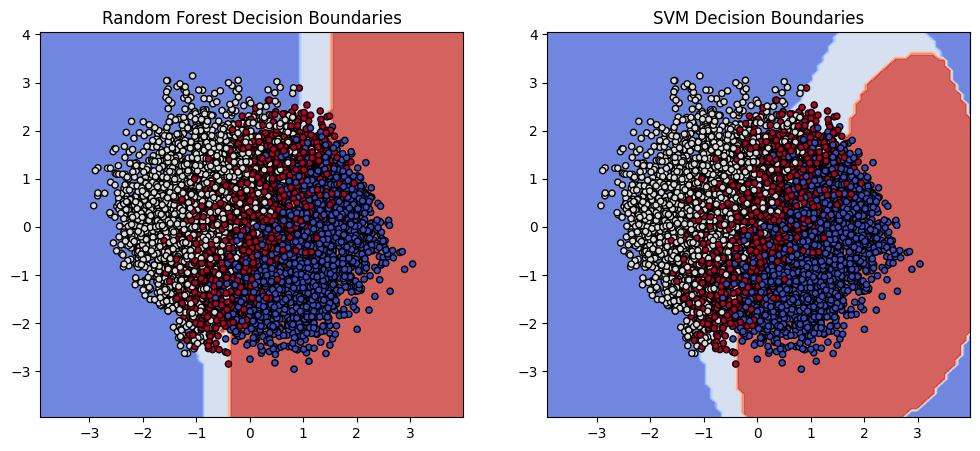

In [14]:
import numpy as np

def plot_contours(ax, clf, xx, yy, **params):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    # تحويل التوقعات النصية إلى أرقام للرسم
    target_map = {'Low': 0, 'Medium': 1, 'High': 2}
    Z = np.array([target_map[inst] for inst in Z])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

# إعداد الشبكة للرسم
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
X0, X1 = X_test[:, 0], X_test[:, 1]
xx, yy = np.meshgrid(np.arange(X0.min()-1, X0.max()+1, 0.1),
                     np.arange(X1.min()-1, X1.max()+1, 0.1))

# رسم حدود Random Forest
plot_contours(ax[0], rf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
ax[0].scatter(X0, X1, c=pd.factorize(y_test)[0], cmap=plt.cm.coolwarm, s=20, edgecolors='k')
ax[0].set_title('Random Forest Decision Boundaries')

# رسم حدود SVM
plot_contours(ax[1], svm, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
ax[1].scatter(X0, X1, c=pd.factorize(y_test)[0], cmap=plt.cm.coolwarm, s=20, edgecolors='k')
ax[1].set_title('SVM Decision Boundaries')

plt.show()

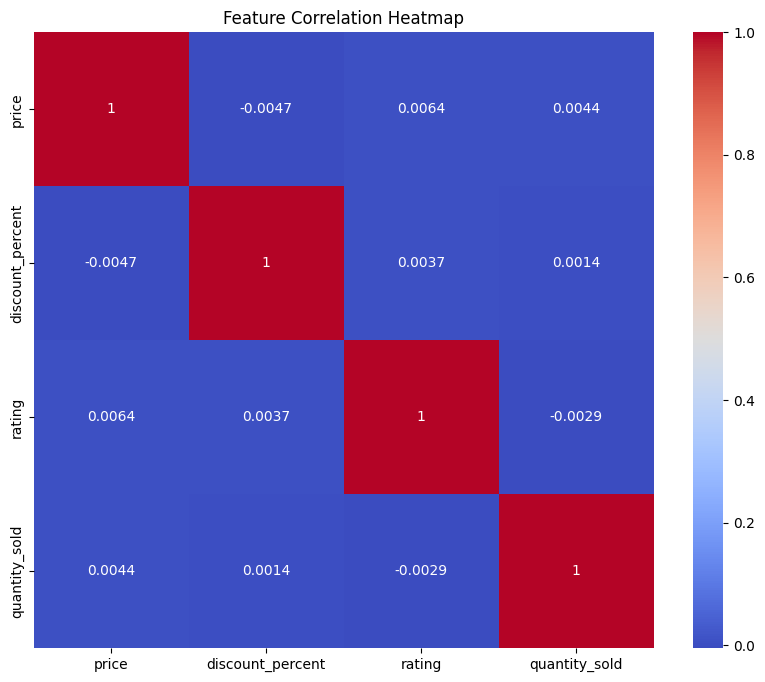

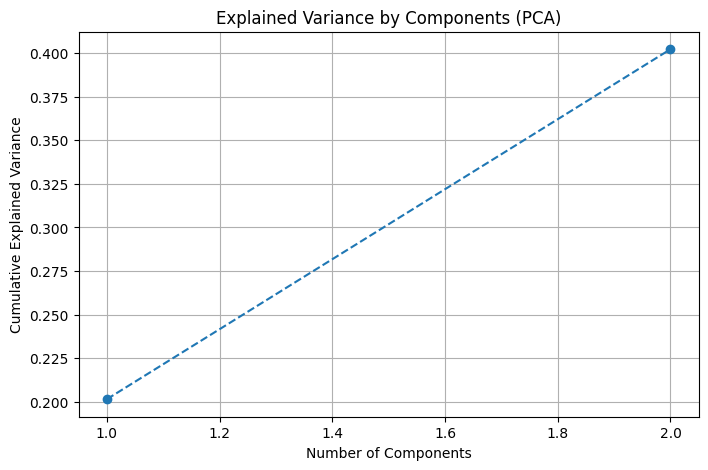

In [15]:
# 1. رسم الـ Correlation Heatmap (لجزء الـ Feature Selection)
plt.figure(figsize=(10, 8))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

# 2. رسم الـ Scree Plot (لجزء الـ Dimension Reduction)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('Explained Variance by Components (PCA)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()

In [17]:
import joblib
from google.colab import files

# تأكد أن هذه الأسماء هي نفسها التي استخدمتها في خلية التدريب
# إذا كنت سميته svm استخدم svm، وإذا كنت سميته svm_model استخدم svm_model
try:
    # 1. حفظ الموديل (تأكد من الاسم هنا)
    joblib.dump(svm, 'amazon_svm_model.pkl')

    # 2. حفظ الـ Scaler
    joblib.dump(scaler, 'scaler.pkl')

    # 3. حفظ الـ PCA
    joblib.dump(pca, 'pca_model.pkl')

    print("✅ تم حفظ الملفات بنجاح!")

    # تنزيل الملفات تلقائياً
    files.download('amazon_svm_model.pkl')
    files.download('scaler.pkl')
    files.download('pca_model.pkl')

except NameError as e:
    print(f"❌ خطأ: لم يتم العثور على المتغير. تأكد من تشغيل خلية التدريب أولاً. التفاصيل: {e}")

✅ تم حفظ الملفات بنجاح!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>